# CT phantom preprocessing pipeline appling paper methods
**Pipeline:** HU conversion → Fat-based normalization → Windowing → Median filter → Threshold segmentation  
**Dataset:** FANTOCCIO — series S2010 and S3010 (571/577 slices, 512×512)

---
### Paper references

| ID | Authors | Year | Journal | Relevance |
|---|---|---|---|---|
| **Nelson** | Nelson et al. | 2008 | Medical Physics | HU reference values for breast tissues; 5-point median filter; Gaussian histogram fitting |
| **Chen** | Chen Z. | 2008 | Computerized Medical Imaging and Graphics | Valley-seeking and five-subinterval threshold segmentation algorithms |
| **Caballo** | Caballo et al. | 2018 | Medical Physics | Unsupervised segmentation; bimodal histogram; DSC benchmark |
| **Prionas** | Prionas et al. | 2010 | Radiology | Fat-based intensity normalization; windowing WW=350 WL=25; lesion HU values |

---
### Folder structure
```
output/
   ├── preprocessing_data/paper_based/
   │   ├── S2010/  (hu_volume.npy, normalized_volume.npy, windowed_volume.npy, filtered_volume.npy, spacing.npy)
   │   └── S3010/  (hu_volume.npy, normalized_volume.npy, windowed_volume.npy, filtered_volume.npy, spacing.npy)
   └── figures/paper_based/
       └── pipeline_S2010.png, segmentation_S2010.png, segA..D_*.png, comparison_*.png
```


In [1]:
# ============================================================
# CELL 1 - Import libraries, output folders, NRRD save helper
# ============================================================
# Requires: pip install SimpleITK --break-system-packages

import os
import numpy as np
import pydicom
import SimpleITK as sitk
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter, gaussian_filter1d
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

# --- locate project root automatically (works whether the notebook is
#     opened from the project root or from notebooks/) ---
PROJECT_ROOT = os.path.abspath(os.getcwd())
for _ in range(6):
    if os.path.isdir(os.path.join(PROJECT_ROOT, "dataset", "FANTOCCIO")):
        break
    parent = os.path.dirname(PROJECT_ROOT)
    if parent == PROJECT_ROOT:
        break
    PROJECT_ROOT = parent

if os.path.abspath(os.getcwd()) != PROJECT_ROOT:
    os.chdir(PROJECT_ROOT)
print(f"Project root        : {PROJECT_ROOT}")
print(f"Current directory   : {os.getcwd()}")

OUTPUT_DIRS = [
    "./output/preprocessing_data/paper_based/S2010",
    "./output/preprocessing_data/paper_based/S3010",
    "./output/figures/paper_based",
]
for d in OUTPUT_DIRS:
    os.makedirs(d, exist_ok=True)

SERIES = {
    "S2010": "./dataset/FANTOCCIO/S72990/S2010",
    "S3010": "./dataset/FANTOCCIO/S72990/S3010",
}


def save_as_nrrd(volume_zyx, geometry, out_path, compress=False):
    """Save (Z, Y, X) numpy as .nrrd with full DICOM geometry, openable
    in 3D Slicer with correct spacing/origin/orientation.
    compress=False (default) is much faster on large float volumes."""
    img = sitk.GetImageFromArray(volume_zyx)
    sp = geometry["spacing"]
    img.SetSpacing((float(sp[2]), float(sp[1]), float(sp[0])))
    img.SetOrigin(tuple(float(c) for c in geometry["origin"]))
    img.SetDirection(tuple(float(c) for c in geometry["direction"]))
    sitk.WriteImage(img, out_path, useCompression=compress)


print("Libraries imported and output structure ready.")


Project root        : /home/andrea/guided_breast_biopsy
Current directory   : /home/andrea/guided_breast_biopsy
Libraries imported and output structure ready.


---
## Step 1 - Hounsfield Unit (HU) Conversion

**Formula:** `HU = pixel_value x RescaleSlope + RescaleIntercept`

Raw DICOM pixel values are scanner-dependent. The HU scale is the only standardised unit
comparable across scanners. Without this conversion no threshold has clinical meaning.

**Reference HU values [Nelson2008, Prionas2010]:**

| Tissue | HU |
|---|---|
| Air | -1000 |
| Adipose | -100 / -50 |
| Fat (dedicated breast CT) | ~126 HU [Nelson2008] |
| Glandular / skin | ~152 HU [Nelson2008] |
| Malignant lesion (post-contrast) | +55.9 HU above baseline [Prionas2010] |
| Benign lesion (post-contrast) | +17.6 HU above baseline [Prionas2010] |
| Bone | 200-400 |
| Metal (phantom seed) | >1000 |


> **Note [Nelson]:** Fat (~126 HU) vs glandular (~152 HU) differ by only ~26 HU, that why simple global thresholding alone is insufficient.


In [2]:
# ============================================================
# CELL 2 - STEP 1: Load DICOM volume + convert to HU + extract geometry
# Ref: Nelson, Prionas
# ============================================================

def load_dicom_volume_hu(folder_path, series_name):
    """Load all DICOM slices, sort by SliceLocation, convert to HU,
    extract spacing/origin/direction. Save .npy and .nrrd."""
    valid_paths = []
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            ds = pydicom.dcmread(fpath, stop_before_pixels=True)
            if hasattr(ds, 'Rows') and hasattr(ds, 'Columns'):
                valid_paths.append(fpath)
        except Exception:
            pass
    if not valid_paths:
        raise FileNotFoundError(f"No valid DICOM files in {folder_path}")

    def get_z(fpath):
        ds = pydicom.dcmread(fpath, stop_before_pixels=True)
        if hasattr(ds, 'SliceLocation'):  return float(ds.SliceLocation)
        if hasattr(ds, 'InstanceNumber'): return float(ds.InstanceNumber)
        return 0.0

    valid_paths.sort(key=get_z)
    print(f"[{series_name}] Slices found and sorted: {len(valid_paths)}")

    slices_hu, first_ds, last_ds = [], None, None
    for fpath in valid_paths:
        ds        = pydicom.dcmread(fpath)
        slope     = float(ds.RescaleSlope)     if hasattr(ds,'RescaleSlope')     else 1.0
        intercept = float(ds.RescaleIntercept) if hasattr(ds,'RescaleIntercept') else 0.0
        slices_hu.append(ds.pixel_array.astype(np.float32) * slope + intercept)
        if first_ds is None: first_ds = ds
        last_ds = ds

    hu_volume = np.stack(slices_hu, axis=0)
    n = len(valid_paths)
    px = first_ds.PixelSpacing if hasattr(first_ds, 'PixelSpacing') else [1.0, 1.0]
    y_mm, x_mm = float(px[0]), float(px[1])

    ipp_first = (np.array(first_ds.ImagePositionPatient, dtype=float)
                 if hasattr(first_ds, 'ImagePositionPatient')
                 else np.array([0., 0., 0.]))
    ipp_last  = (np.array(last_ds.ImagePositionPatient, dtype=float)
                 if hasattr(last_ds, 'ImagePositionPatient')
                 else np.array([0., 0., float(n - 1)]))
    z_mm = float(np.linalg.norm(ipp_last - ipp_first) / max(n - 1, 1))
    if z_mm == 0.0:
        z_mm = float(first_ds.SliceThickness) if hasattr(first_ds, 'SliceThickness') else 1.0
    spacing = (z_mm, y_mm, x_mm)

    iop = (first_ds.ImageOrientationPatient
           if hasattr(first_ds, 'ImageOrientationPatient')
           else [1, 0, 0, 0, 1, 0])
    row_dir = np.array(iop[0:3], dtype=float)
    col_dir = np.array(iop[3:6], dtype=float)
    slice_vec = ipp_last - ipp_first
    if np.linalg.norm(slice_vec) > 0:
        slice_dir = slice_vec / np.linalg.norm(slice_vec)
    else:
        slice_dir = np.cross(row_dir, col_dir)

    direction = (
        row_dir[0], col_dir[0], slice_dir[0],
        row_dir[1], col_dir[1], slice_dir[1],
        row_dir[2], col_dir[2], slice_dir[2],
    )

    geometry = {
        "spacing":   spacing,
        "origin":    tuple(ipp_first.tolist()),
        "direction": tuple(float(c) for c in direction),
    }

    out_dir = f"./output/preprocessing_data/paper_based/{series_name}"
    np.save(f"{out_dir}/hu_volume.npy", hu_volume)
    np.save(f"{out_dir}/spacing.npy",   np.array(spacing))
    save_as_nrrd(hu_volume, geometry, f"{out_dir}/hu_volume.nrrd")

    print(f"[{series_name}] Shape:   {hu_volume.shape}")
    print(f"[{series_name}] HU:      min={hu_volume.min():.0f}  max={hu_volume.max():.0f}")
    print(f"[{series_name}] Voxel:   Z={spacing[0]:.3f} Y={spacing[1]:.4f} X={spacing[2]:.4f} mm")
    print(f"[{series_name}] Saved:   hu_volume.npy, spacing.npy, hu_volume.nrrd")
    print("-" * 60)
    return hu_volume, spacing, geometry


print("=== STEP 1: HU Conversion + DICOM geometry ===")
hu_S2010, spacing_S2010, geom_S2010 = load_dicom_volume_hu(SERIES["S2010"], "S2010")
hu_S3010, spacing_S3010, geom_S3010 = load_dicom_volume_hu(SERIES["S3010"], "S3010")


=== STEP 1: HU Conversion + DICOM geometry ===
[S2010] Slices found and sorted: 571
[S2010] Shape:   (571, 512, 512)
[S2010] HU:      min=-1024  max=3071
[S2010] Voxel:   Z=0.335 Y=0.3789 X=0.3789 mm
[S2010] Saved:   hu_volume.npy, spacing.npy, hu_volume.nrrd
------------------------------------------------------------
[S3010] Slices found and sorted: 577
[S3010] Shape:   (577, 512, 512)
[S3010] HU:      min=-1024  max=3071
[S3010] Voxel:   Z=0.335 Y=0.3340 X=0.3340 mm
[S3010] Saved:   hu_volume.npy, spacing.npy, hu_volume.nrrd
------------------------------------------------------------


---
## Step 2 - Fat-based Intensity Normalization

**Method [Prionas]:** `HU_norm = HU_voxel - HU_mean_fat`

Adipose tissue is the most stable internal reference: constant HU across scanners,
unaffected by contrast agent, always present in breast CT.

> **[Prionas]:** Enhancement = `(HU_lesion_post - HU_fat_post) - (HU_lesion_pre - HU_fat_pre)`
> Fat subtracted as internal reference to remove inter-session fluctuations.


In [3]:
# ============================================================
# CELL 3 - STEP 2: Fat-based intensity normalization
# Ref: Prionas
# ============================================================

def normalize_by_fat(hu_volume, geometry, series_name,
                     fat_hu_min=-200, fat_hu_max=-50):
    """Subtract mean HU of fat voxels [Prionas]. Output still in HU."""
    fat_mask   = (hu_volume >= fat_hu_min) & (hu_volume <= fat_hu_max)
    fat_voxels = hu_volume[fat_mask]
    if fat_voxels.size == 0:
        print(f"[{series_name}] WARNING: No fat voxels found.")
        return hu_volume, 0.0
    hu_mean_fat = float(np.mean(fat_voxels))
    normalized  = hu_volume - hu_mean_fat

    out_dir = f"./output/preprocessing_data/paper_based/{series_name}"
    np.save(f"{out_dir}/normalized_volume.npy", normalized)
    save_as_nrrd(normalized, geometry, f"{out_dir}/normalized_volume.nrrd")

    print(f"[{series_name}] Fat voxels: {fat_voxels.size:,} | mean HU fat: {hu_mean_fat:.2f} HU")
    print(f"[{series_name}] Saved: normalized_volume.npy, normalized_volume.nrrd")
    print("-" * 60)
    return normalized, hu_mean_fat


print("=== STEP 2: Fat-based Normalization [Prionas] ===")
norm_S2010, fat_hu_S2010 = normalize_by_fat(hu_S2010, geom_S2010, "S2010")
norm_S3010, fat_hu_S3010 = normalize_by_fat(hu_S3010, geom_S3010, "S3010")


=== STEP 2: Fat-based Normalization [Prionas] ===
[S2010] Fat voxels: 6,882,905 | mean HU fat: -157.81 HU
[S2010] Saved: normalized_volume.npy, normalized_volume.nrrd
------------------------------------------------------------
[S3010] Fat voxels: 11,321,434 | mean HU fat: -152.19 HU
[S3010] Saved: normalized_volume.npy, normalized_volume.nrrd
------------------------------------------------------------


---
## Step 3 - Windowing

**Parameters [Prionas]:** WW=350 HU | WL=25 HU → range [-150, +200] HU

Clinically validated for breast CT. Keeps adipose (-100 HU), glandular (+152 HU), lesions.
Clips bone and metal (>200 HU) to remove beam-hardening artefacts.

> Applied on the **original HU volume** (not normalized) to preserve the absolute clinical meaning.


In [4]:
# ============================================================
# CELL 4 - STEP 3: Windowing
# Ref: Prionas (WW=350, WL=25)
# After this step the data is in [0, 1].
# ============================================================

def apply_windowing(hu_volume, geometry, series_name,
                    window_width=350, window_level=25):
    """CT windowing for breast CT [Prionas]: WW=350, WL=25 -> [-150, +200] HU,
    rescaled to [0, 1] for visualization and downstream thresholding."""
    lower = window_level - window_width / 2
    upper = window_level + window_width / 2
    windowed = np.clip(hu_volume, lower, upper)
    windowed = (windowed - lower) / (upper - lower)

    out_dir = f"./output/preprocessing_data/paper_based/{series_name}"
    np.save(f"{out_dir}/windowed_volume.npy", windowed)
    save_as_nrrd(windowed, geometry, f"{out_dir}/windowed_volume.nrrd")

    print(f"[{series_name}] WW={window_width} WL={window_level} -> [{lower:.0f}, {upper:.0f}] HU [Prionas]")
    print(f"[{series_name}] Output rescaled to [0, 1].")
    print(f"[{series_name}] Saved: windowed_volume.npy, windowed_volume.nrrd")
    print("-" * 60)
    return windowed


print("=== STEP 3: Windowing [Prionas] ===")
windowed_S2010 = apply_windowing(hu_S2010, geom_S2010, "S2010")
windowed_S3010 = apply_windowing(hu_S3010, geom_S3010, "S3010")


=== STEP 3: Windowing [Prionas] ===
[S2010] WW=350 WL=25 -> [-150, 200] HU [Prionas]
[S2010] Output rescaled to [0, 1].
[S2010] Saved: windowed_volume.npy, windowed_volume.nrrd
------------------------------------------------------------
[S3010] WW=350 WL=25 -> [-150, 200] HU [Prionas]
[S3010] Output rescaled to [0, 1].
[S3010] Saved: windowed_volume.npy, windowed_volume.nrrd
------------------------------------------------------------


---
## Step 4 - Noise Reduction: 5-point Median Filter

**Method [Nelson]:** 5-point median filter slice by slice before histogram analysis.

Edge-preserving: reduces Poisson noise without blurring tissue boundaries.
Critical given the narrow ~26 HU gap between fat and glandular tissue.


In [5]:
# ============================================================
# CELL 5 - STEP 4: 5-point median filter
# Ref: Nelson
# ============================================================
# Output: filtered_volume in [0, 1].
# This is THE volume used both for:
#   - the threshold computed in STEP 5
#   - 3D Slicer (load filtered_volume.nrrd, apply same threshold value)

def apply_median_filter(windowed_volume, geometry, series_name, kernel_size=5):
    """5-point median filter slice by slice [Nelson]. Output stays in [0, 1]."""
    n = windowed_volume.shape[0]
    filtered_volume = np.zeros_like(windowed_volume)
    for i in range(n):
        filtered_volume[i] = median_filter(windowed_volume[i], size=kernel_size)
        if (i + 1) % 100 == 0:
            print(f"  [{series_name}] {i+1}/{n} filtered...")

    out_dir = f"./output/preprocessing_data/paper_based/{series_name}"
    np.save(f"{out_dir}/filtered_volume.npy", filtered_volume)
    save_as_nrrd(filtered_volume, geometry, f"{out_dir}/filtered_volume.nrrd")

    print(f"[{series_name}] Median filter {kernel_size}x{kernel_size} complete [Nelson]")
    print(f"[{series_name}] Range: [{filtered_volume.min():.3f}, {filtered_volume.max():.3f}]")
    print(f"[{series_name}] Saved: filtered_volume.npy, filtered_volume.nrrd")
    print(f"[{series_name}] -> use this file in 3D Slicer for thresholding")
    print("-" * 60)
    return filtered_volume


print("=== STEP 4: 5-point Median Filter [Nelson] ===")
filtered_S2010 = apply_median_filter(windowed_S2010, geom_S2010, "S2010")
filtered_S3010 = apply_median_filter(windowed_S3010, geom_S3010, "S3010")


=== STEP 4: 5-point Median Filter [Nelson] ===
  [S2010] 100/571 filtered...
  [S2010] 200/571 filtered...
  [S2010] 300/571 filtered...
  [S2010] 400/571 filtered...
  [S2010] 500/571 filtered...
[S2010] Median filter 5x5 complete [Nelson]
[S2010] Range: [0.000, 1.000]
[S2010] Saved: filtered_volume.npy, filtered_volume.nrrd
[S2010] -> use this file in 3D Slicer for thresholding
------------------------------------------------------------
  [S3010] 100/577 filtered...
  [S3010] 200/577 filtered...
  [S3010] 300/577 filtered...
  [S3010] 400/577 filtered...
  [S3010] 500/577 filtered...
[S3010] Median filter 5x5 complete [Nelson]
[S3010] Range: [0.000, 1.000]
[S3010] Saved: filtered_volume.npy, filtered_volume.nrrd
[S3010] -> use this file in 3D Slicer for thresholding
------------------------------------------------------------


In [ ]:
# ============================================================
# CELL 5.1: Invert the [0,1] rescale back to windowed HU
# ============================================================
# filtered_volume is the end of the pipeline, rescaled to [0,1] in STEP 3 via
#   windowed = (clip(HU, -150, +200) + 150) / 350
# This inverts ONLY that rescale, returning the same processed volume in HU
# (band [-150, +200]). Same processing, just HU units for Slicer segmentation.

WINDOW_WIDTH, WINDOW_LEVEL = 350, 25
LOWER = WINDOW_LEVEL - WINDOW_WIDTH / 2   # -150
UPPER = WINDOW_LEVEL + WINDOW_WIDTH / 2   # +200

def filtered_to_hu(filtered_volume, geometry, series_name):
    """Map filtered_volume [0,1] back to windowed HU: HU = v*(UPPER-LOWER)+LOWER."""
    filtered_hu = filtered_volume * (UPPER - LOWER) + LOWER   # [0,1] -> [-150, +200] HU

    out_dir = f"./output/preprocessing_data/paper_based/{series_name}"
    np.save(f"{out_dir}/filtered_volume_hu.npy", filtered_hu)
    save_as_nrrd(filtered_hu, geometry, f"{out_dir}/filtered_volume_hu.nrrd")

    print(f"[{series_name}] Inverted [0,1] -> windowed HU band [{LOWER:.0f}, {UPPER:.0f}]")
    print(f"[{series_name}] HU range: [{filtered_hu.min():.1f}, {filtered_hu.max():.1f}]")
    print(f"[{series_name}] Saved: filtered_volume_hu.npy, filtered_volume_hu.nrrd")
    print(f"[{series_name}] -> load THIS in 3D Slicer for HU-based segmentation")
    print("-" * 60)
    return filtered_hu

print("=== STEP 4-HU: invert [0,1] rescale back to HU ===")
filtered_hu_S2010 = filtered_to_hu(filtered_S2010, geom_S2010, "S2010")
filtered_hu_S3010 = filtered_to_hu(filtered_S3010, geom_S3010, "S3010")

=== STEP 4-HU: invert [0,1] rescale back to HU ===
[S2010] Inverted [0,1] -> windowed HU band [-150, 200]
[S2010] HU range: [-150.0, 200.0]
[S2010] Saved: filtered_volume_hu.npy, filtered_volume_hu.nrrd
[S2010] -> load THIS in 3D Slicer for HU-based segmentation
------------------------------------------------------------
[S3010] Inverted [0,1] -> windowed HU band [-150, 200]
[S3010] HU range: [-150.0, 200.0]
[S3010] Saved: filtered_volume_hu.npy, filtered_volume_hu.nrrd
[S3010] -> load THIS in 3D Slicer for HU-based segmentation
------------------------------------------------------------


---
## Visualization - Full pipeline comparison

4 rows × 3 slices (25% / 50% / 75% of volume depth).


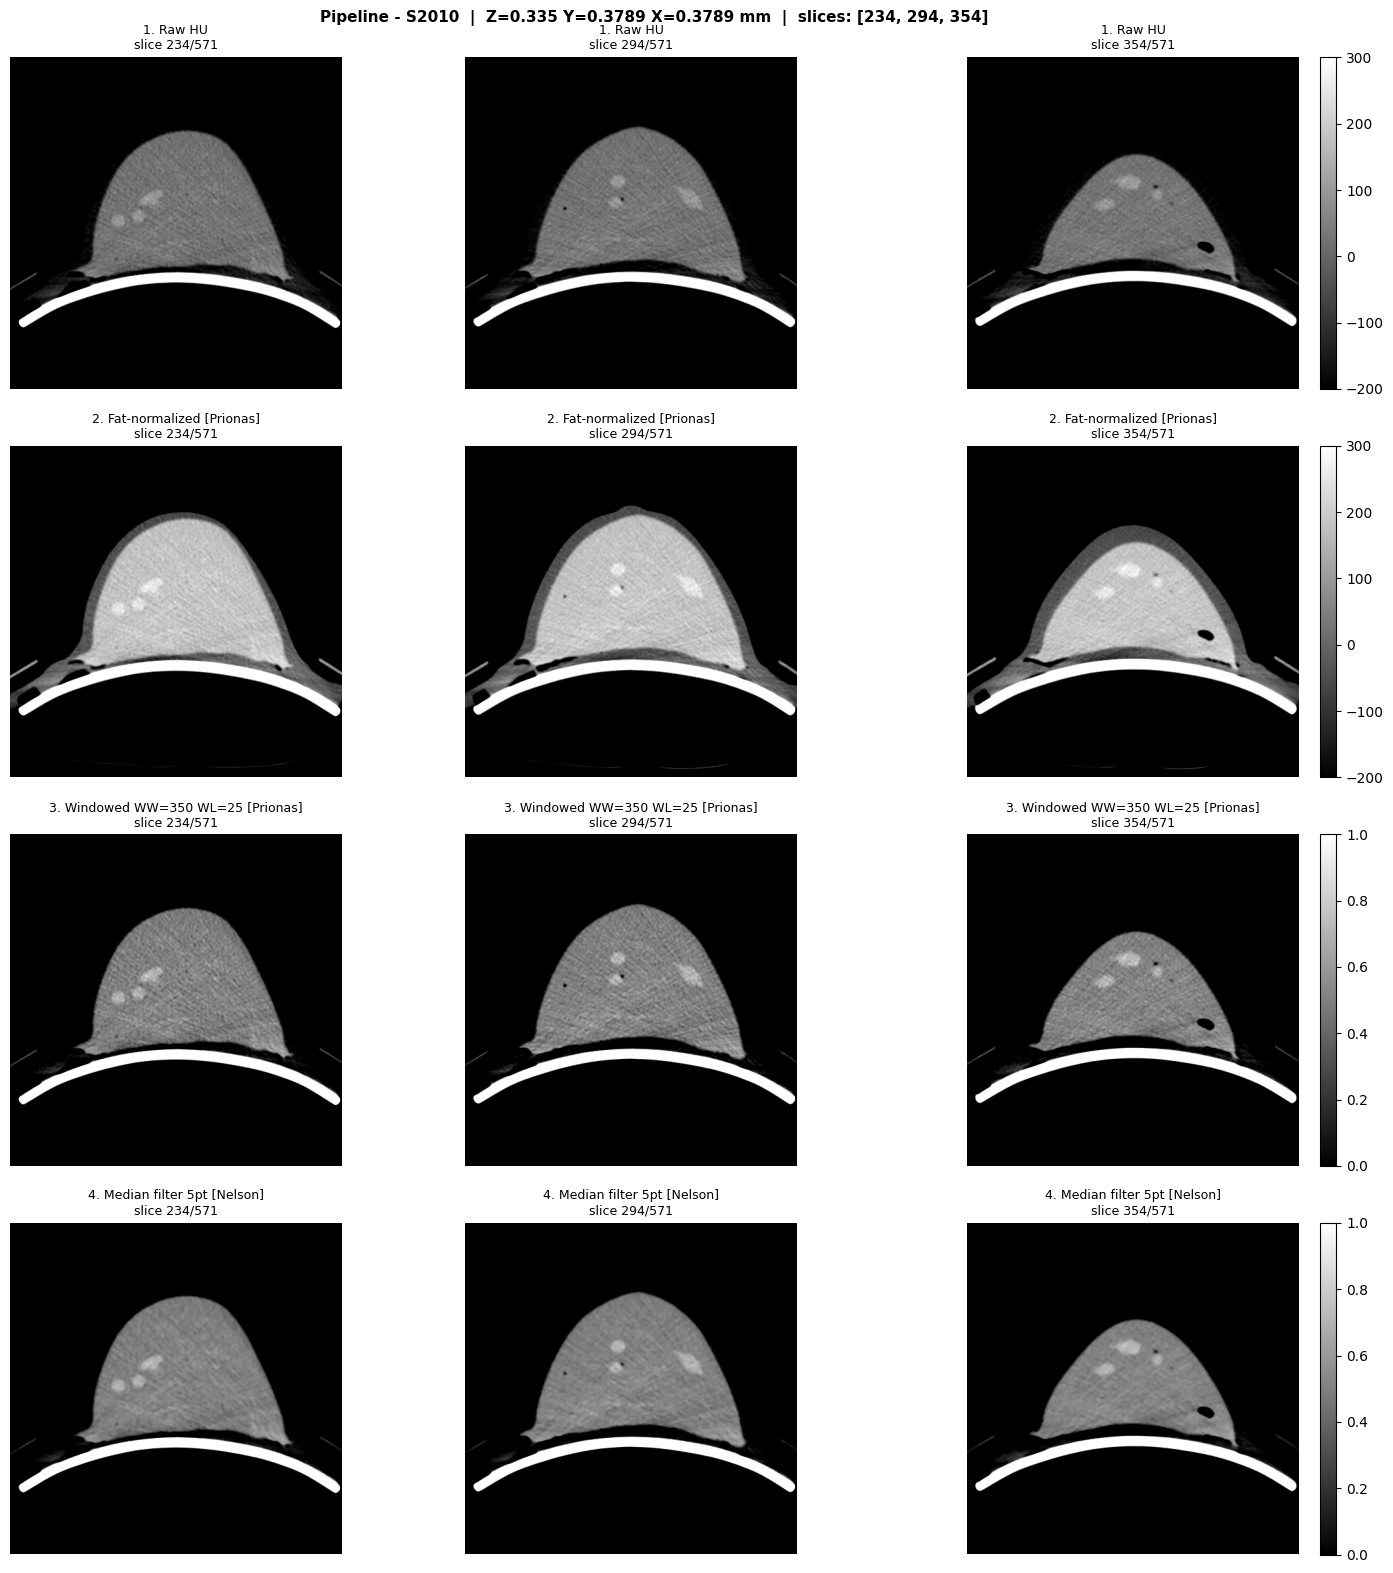

[S2010] Saved: ./output/figures/paper_based/pipeline_S2010.png


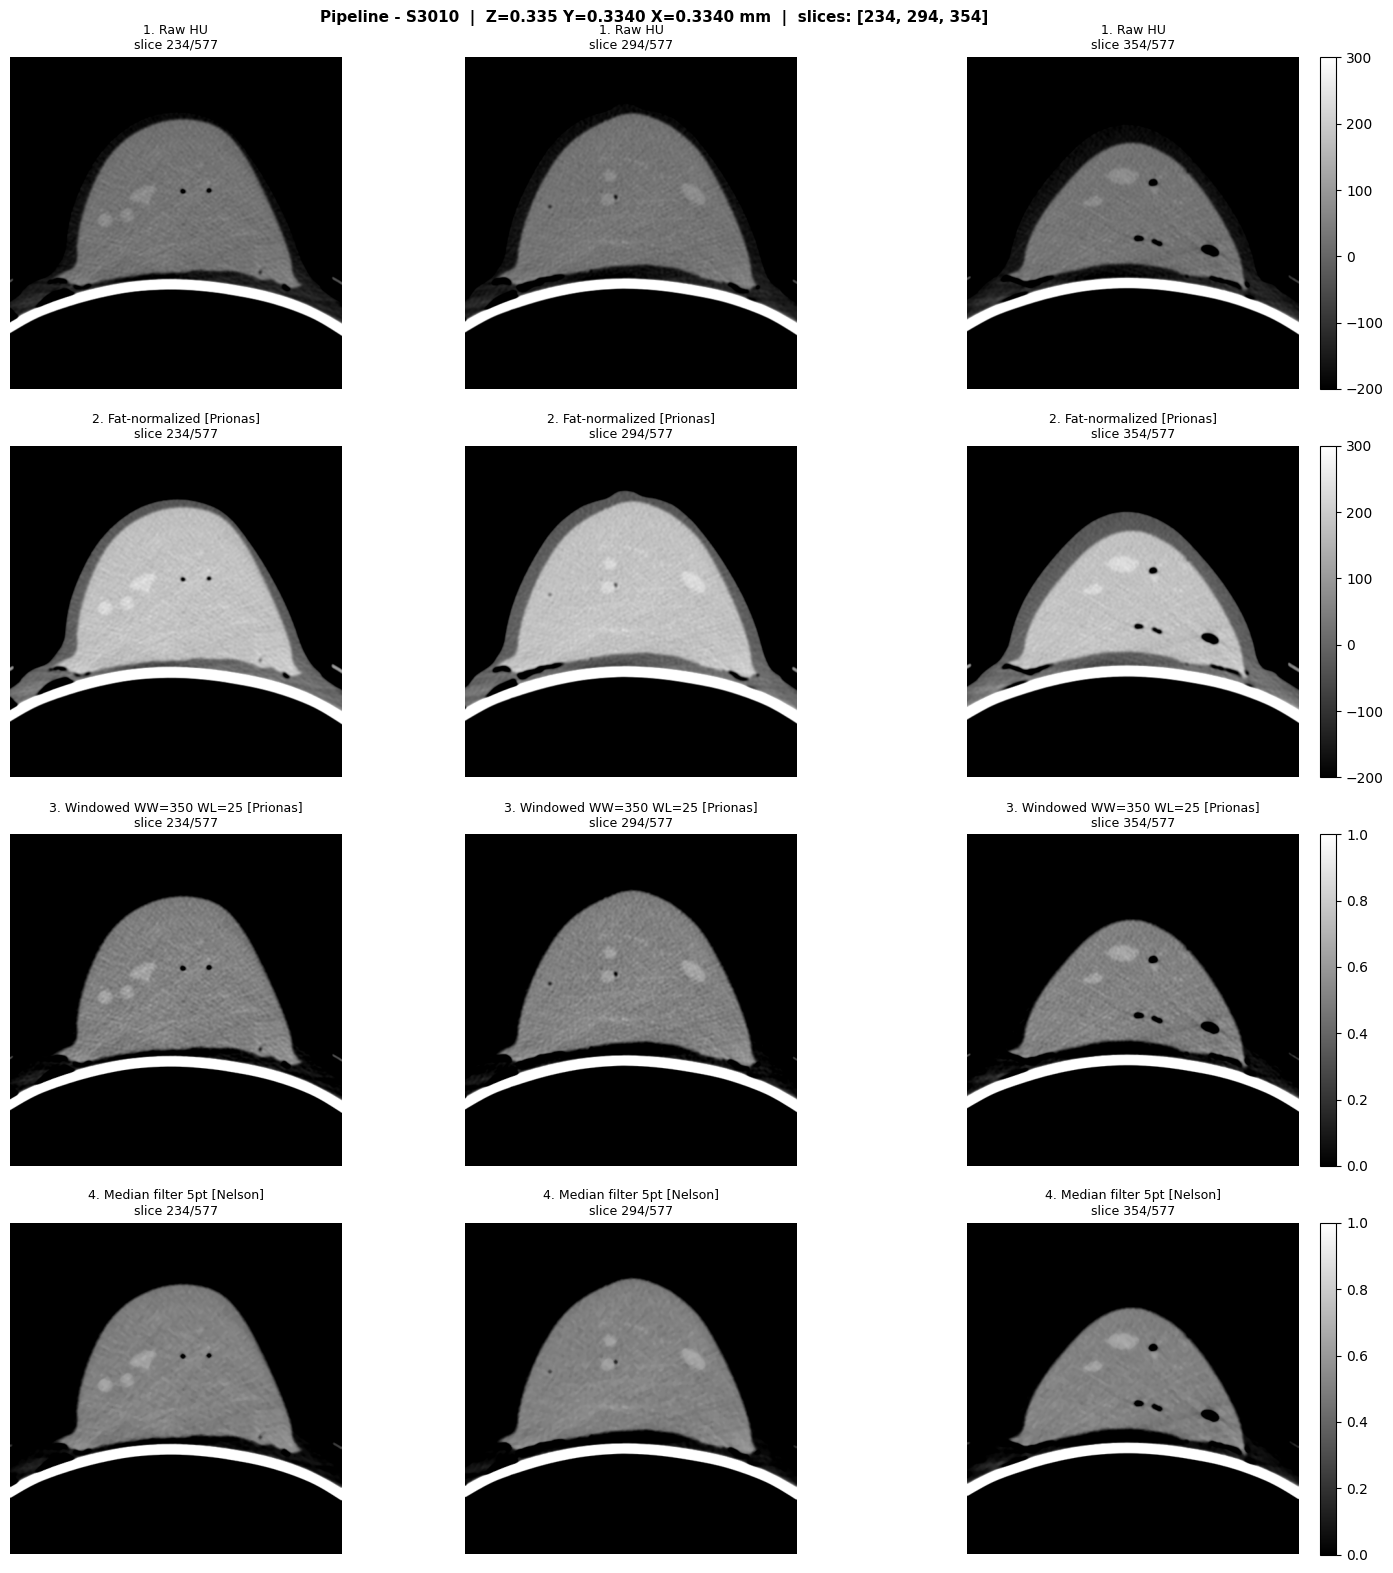

[S3010] Saved: ./output/figures/paper_based/pipeline_S3010.png


In [7]:
# ============================================================
# CELL 6 - Full pipeline visualization (4 rows x 3 slices)
# ============================================================
# Fixed slices [234, 294, 354] for both series, chosen as representative
# central frames where the phantom is well visible.

PIPELINE_SLICES = [234, 294, 354]


def visualize_full_pipeline(hu_vol, norm_vol, wind_vol, filt_vol,
                            series_name, spacing,
                            slice_indices=PIPELINE_SLICES):
    n = hu_vol.shape[0]
    idxs = [s for s in slice_indices if 0 <= s < n]

    rows_data = [
        (hu_vol,   "1. Raw HU",                          dict(vmin=-200, vmax=300)),
        (norm_vol, "2. Fat-normalized [Prionas]",        dict(vmin=-200, vmax=300)),
        (wind_vol, "3. Windowed WW=350 WL=25 [Prionas]", dict(vmin=0,    vmax=1)),
        (filt_vol, "4. Median filter 5pt [Nelson]",      dict(vmin=0,    vmax=1)),
    ]

    fig, axes = plt.subplots(4, len(idxs), figsize=(5 * len(idxs), 16))
    fig.suptitle(f"Pipeline - {series_name}  |  "
                 f"Z={spacing[0]:.3f} Y={spacing[1]:.4f} X={spacing[2]:.4f} mm  |  "
                 f"slices: {idxs}",
                 fontsize=11, fontweight='bold')

    for row_idx, (vol, label, kwargs) in enumerate(rows_data):
        for col_idx, sl in enumerate(idxs):
            ax = axes[row_idx, col_idx]
            im = ax.imshow(vol[sl], cmap='gray', **kwargs)
            ax.set_title(f"{label}\nslice {sl}/{n}", fontsize=9)
            ax.axis('off')
            if col_idx == len(idxs) - 1:
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    out = f"./output/figures/paper_based/pipeline_{series_name}.png"
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"[{series_name}] Saved: {out}")


visualize_full_pipeline(hu_S2010, norm_S2010, windowed_S2010, filtered_S2010,
                        "S2010", spacing_S2010)
visualize_full_pipeline(hu_S3010, norm_S3010, windowed_S3010, filtered_S3010,
                        "S3010", spacing_S3010)


---
## Step 5 - Threshold-based Segmentation

Main deliverable for the 30/03 meeting.

| Histogram | Algorithm | When |
|---|---|---|
| Multimodal | Valley-seeking [Chen] | Real patient data |
| Unimodal | Five-subinterval [Chen] | Phantom data |

**Expected threshold [Nelson2008]:** 130-145 HU (valley between fat ~126 and glandular ~152).

**Quality without ground truth [Prionas, Caballo]:**
1. Mean HU per region vs. literature values
2. Tissue proportions: ~73% fat / ~17% glandular [Nelson]
3. Visual inspection of histogram with threshold annotated


## Step 6 — Bright inclusions threshold

After the pipeline (Steps 1–4), the volume `filtered_volume` is in the range `[0, 1]`. We want to isolate the **bright inclusions** (cancer-mimicking structures) inside the phantom body.

### Method

The histogram of `filtered_volume` (restricted to voxels inside the phantom body, range `[0.30, 0.85]`) shows a dominant peak corresponding to the glandular-mimicking material. Bright inclusions appear as a **right-side tail** of this peak: they are denser than the surrounding glandular tissue, but not as bright as the phantom membrane or table.

Following Nelson 2008 (Gaussian histogram fitting on tissue peaks), we:

1. Detect the glandular peak position with `find_peaks` on the smoothed histogram (smoothing only for peak localisation).
2. Fit a Gaussian on the **left side** of the peak (where the inclusion tail does not bias `sigma`), keeping `mu_g` fixed at the data peak.
3. Define the inclusion threshold as

$$ t = \mu_g + k \cdot \sigma_g $$

where `k` controls how far into the right tail we cut. Larger `k` → only the brightest voxels are kept.

### k parameter

The pipeline computes the threshold for `k ∈ {0.5, 1.0, 1.5, 2.0}` and saves the mask for `k = 1.0` as `mask_inclusions.nrrd`. You can compare the four values visually and change `K_DEFAULT` if needed.

### Output for 3D Slicer

`filtered_volume.nrrd` is the post-pipeline volume in `[0, 1]`. Open it in Slicer, go to Segment Editor → Threshold, and set the lower bound to the value printed below for the chosen `k`. The Python segmentation and the Slicer one will overlap 1:1.

In [17]:
# ============================================================
# CONFIG - STEP 5: Threshold for bright inclusions
# ============================================================
SEG_VOLUME = {
    "S2010": filtered_S2010,
    "S3010": filtered_S3010,
}

# Histogram range and bins for the [0, 1] domain
HIST_RANGE = (0.0, 1.0)
N_BINS     = 200

# Smoothing for peak DETECTION ONLY.
# The Gaussian fit (sigma) and the final threshold are computed on the
# ORIGINAL (non-smoothed) histogram. mu_g is fixed at the data peak.
SMOOTH_SIGMA = 3

# Threshold formula: t = mu_g + k * sigma_g
K_VALUES  = [0.5, 1.0, 2.0, 2.5, 3]
K_DEFAULT = 3   # value used to save mask_inclusions.nrrd

# Phantom body band (excludes air on the left, table/membrane on the right)
PHANTOM_MIN = 0.30
PHANTOM_MAX = 0.85

print("Config loaded.")
print(f"  SEG_VOLUME       : filtered_volume (range [0, 1])")
print(f"  Histogram range  : {HIST_RANGE}, bins = {N_BINS}")
print(f"  Smooth sigma     : {SMOOTH_SIGMA}  (peak detection only)")
print(f"  k values         : {K_VALUES}  (default saved: k = {K_DEFAULT})")
print(f"  Phantom band     : [{PHANTOM_MIN}, {PHANTOM_MAX}]")

Config loaded.
  SEG_VOLUME       : filtered_volume (range [0, 1])
  Histogram range  : (0.0, 1.0), bins = 200
  Smooth sigma     : 3  (peak detection only)
  k values         : [0.5, 1.0, 2.0, 2.5, 3]  (default saved: k = 3)
  Phantom band     : [0.3, 0.85]


In [18]:
# ============================================================
# CELL 7 - STEP 5a: Glandular peak detection + Gaussian sigma fit
# Ref: Nelson (Gaussian histogram fitting), Chen (peak detection)
# ============================================================
# mu_g is the position of the DATA peak (find_peaks on smoothed histogram).
# sigma_g comes from a Gaussian fit on the LEFT side of the peak only,
# so the right-tail inclusions do not inflate sigma.

def gaussian(x, A, mu, sigma):
    return A * np.exp(-((x - mu) ** 2) / (2.0 * sigma ** 2))


def fit_glandular_peak(seg_volume, series_name,
                        hist_range=HIST_RANGE, n_bins=N_BINS,
                        phantom_min=PHANTOM_MIN, phantom_max=PHANTOM_MAX):
    flat   = seg_volume.flatten()
    inside = flat[(flat >= phantom_min) & (flat <= phantom_max)]
    print(f"[{series_name}] Voxels in phantom band [{phantom_min}, {phantom_max}]: "
          f"{inside.size:,} ({100.0*inside.size/flat.size:.1f}% of volume)")

    hist_in, edges = np.histogram(inside, bins=n_bins, range=hist_range)
    centers        = (edges[:-1] + edges[1:]) / 2

    # Smooth ONLY for peak detection
    hist_s = gaussian_filter1d(hist_in.astype(float), sigma=SMOOTH_SIGMA)
    peaks, _ = find_peaks(hist_s,
                          prominence=hist_s.max() * 0.05,
                          distance=n_bins // 30)

    print(f"[{series_name}] Peaks found in phantom band: {len(peaks)}")
    for p in peaks:
        print(f"  -> intensity = {centers[p]:.4f}  ({hist_in[p]:,} voxels)")

    if len(peaks) < 1:
        print(f"[{series_name}] ERROR: no peaks found.")
        return None

    # mu_g = position of the DATA peak (rightmost peak = glandular)
    p_gland = peaks[-1] if len(peaks) >= 2 else peaks[0]
    mu_g    = float(centers[p_gland])

    # Fit Gaussian only on the LEFT side of the peak to estimate sigma.
    # mu is held FIXED at mu_g during the fit (we only fit A and sigma).
    win_lo, win_hi = mu_g - 0.06, mu_g + 0.005
    mask = (centers >= win_lo) & (centers <= win_hi)

    def gauss_fixed_mu(x, A, sigma):
        return A * np.exp(-((x - mu_g) ** 2) / (2.0 * sigma ** 2))

    p0 = [float(hist_in[p_gland]), 0.02]
    try:
        popt, _ = curve_fit(gauss_fixed_mu, centers[mask],
                            hist_in[mask].astype(float),
                            p0=p0, maxfev=5000)
        A_fit, sigma_g = popt
        sigma_g = abs(sigma_g)
    except Exception as e:
        print(f"[{series_name}] Fit failed ({e}). Using fallback sigma=0.025.")
        A_fit, sigma_g = float(hist_in[p_gland]), 0.025

    # Reconstruct full popt (mu, A, sigma) for plotting
    popt_full = (A_fit, mu_g, sigma_g)

    print(f"[{series_name}] Glandular peak (data)    : mu_g    = {mu_g:.4f}")
    print(f"[{series_name}] Gaussian fit (left side) : sigma_g = {sigma_g:.4f}")

    return {"mu": mu_g, "sigma": sigma_g,
            "popt": popt_full,
            "hist_in":     hist_in,
            "centers":     centers,
            "peaks":       peaks,
            "phantom_min": phantom_min,
            "phantom_max": phantom_max}


print("=== STEP 5a: Glandular peak fit (filtered_volume, [0, 1]) ===")
fit_S2010 = fit_glandular_peak(SEG_VOLUME["S2010"], "S2010")
fit_S3010 = fit_glandular_peak(SEG_VOLUME["S3010"], "S3010")

=== STEP 5a: Glandular peak fit (filtered_volume, [0, 1]) ===
[S2010] Voxels in phantom band [0.3, 0.85]: 10,280,025 (6.9% of volume)
[S2010] Peaks found in phantom band: 1
  -> intensity = 0.5075  (681,727 voxels)
[S2010] Glandular peak (data)    : mu_g    = 0.5075
[S2010] Gaussian fit (left side) : sigma_g = 0.0308
[S3010] Voxels in phantom band [0.3, 0.85]: 13,351,547 (8.8% of volume)
[S3010] Peaks found in phantom band: 1
  -> intensity = 0.5075  (1,310,399 voxels)
[S3010] Glandular peak (data)    : mu_g    = 0.5075
[S3010] Gaussian fit (left side) : sigma_g = 0.0196


=== STEP 5b: Bright inclusions threshold ===



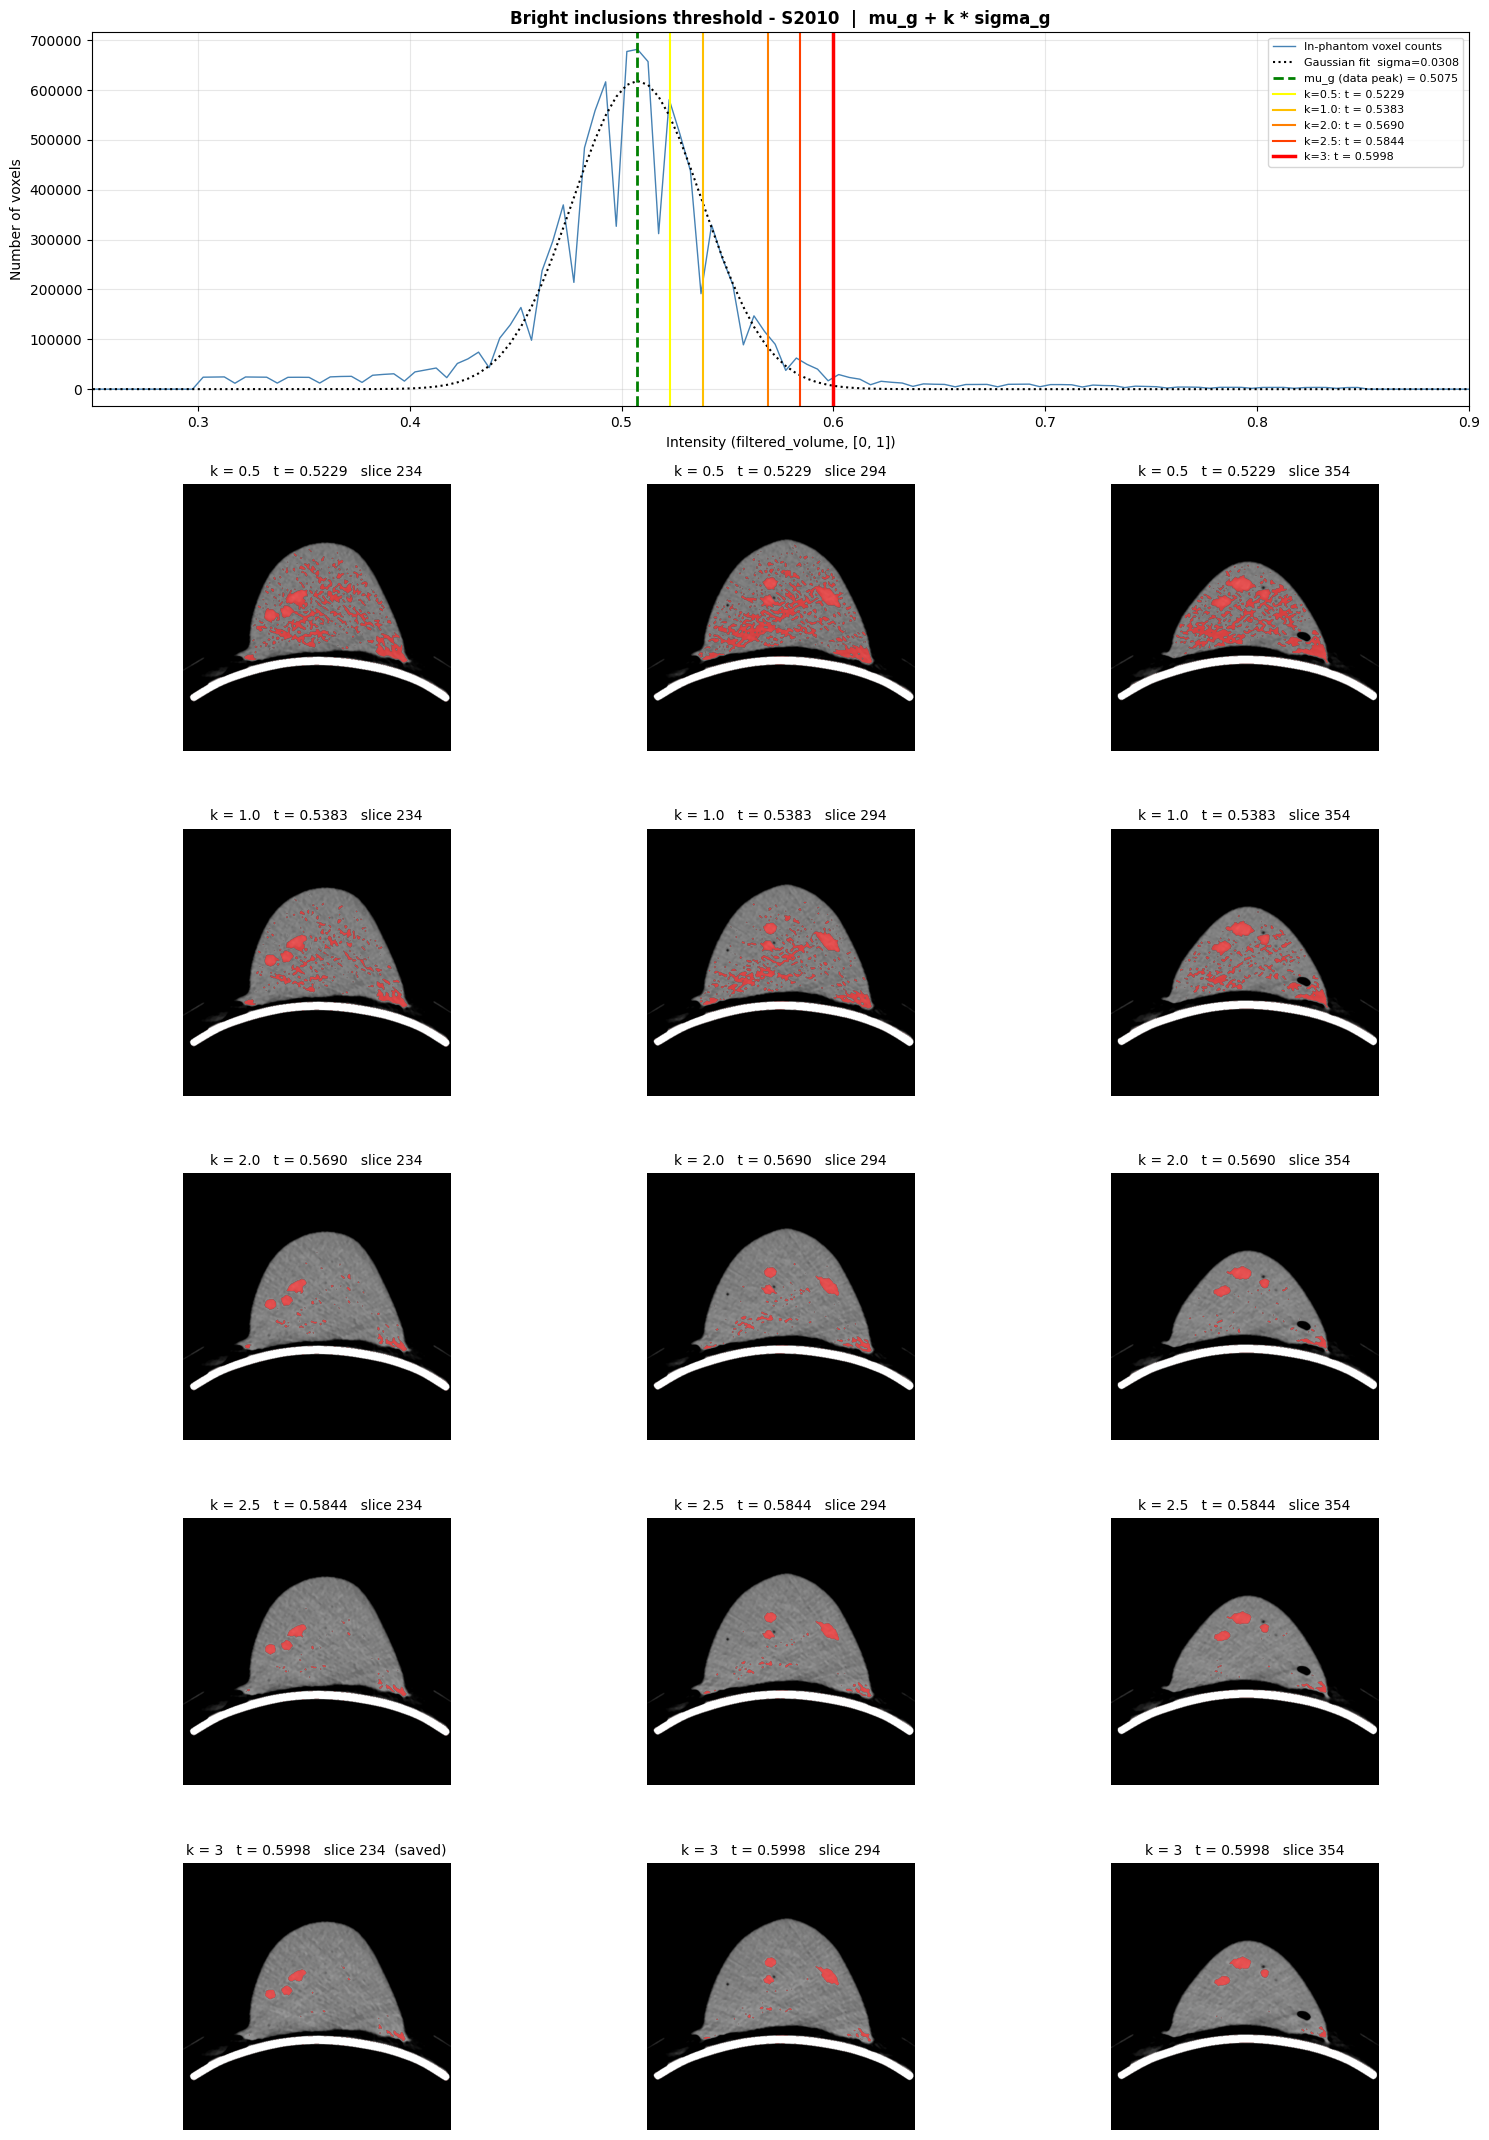

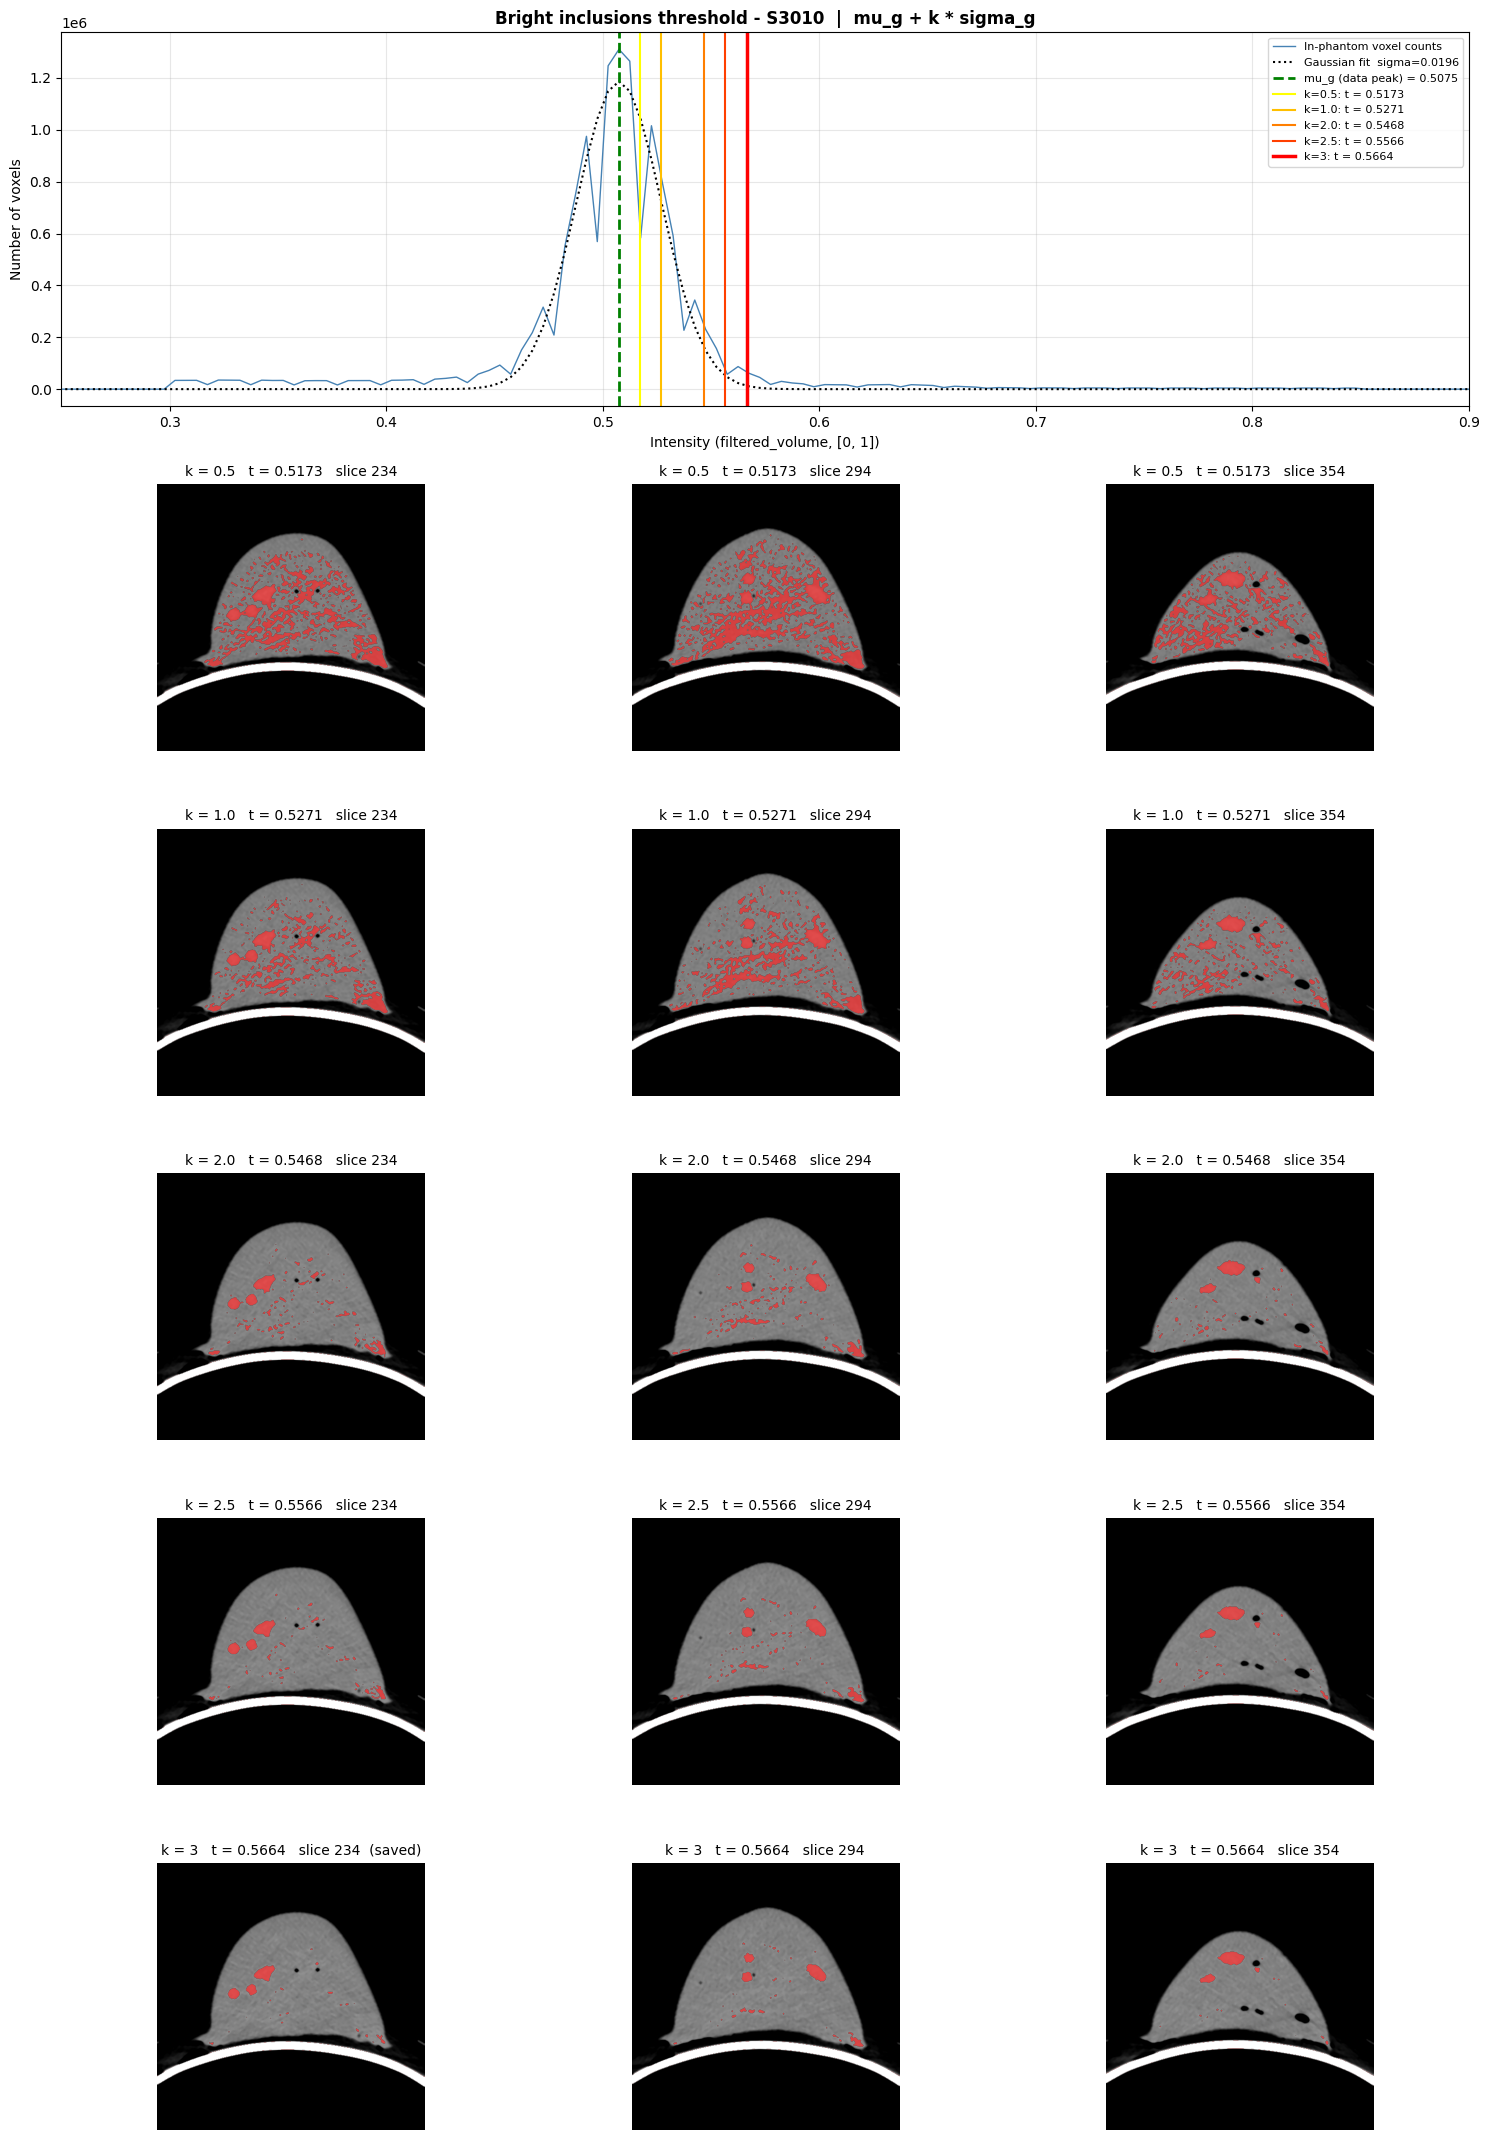


BRIGHT INCLUSIONS - Threshold formula and results

  Formula:   t = mu_g + k * sigma_g
  Where:
    mu_g     = position of the glandular peak in the in-phantom histogram
    sigma_g  = standard deviation from Gaussian fit on the LEFT side
               of the peak (so the inclusion right-tail does not bias it)
    k        = scale factor (larger k -> stricter threshold)

  Domain: filtered_volume in [0, 1]  (post pipeline, median-filtered)

------------------------------------------------------------------------------
  S2010    mu_g = 0.5075    sigma_g = 0.0308

       k    threshold t         voxels     volume cm3    saved
    0.50         0.5229      2,957,909         142.26    
    1.00         0.5383      1,815,909          87.34    
    2.00         0.5690        661,410          31.81    
    2.50         0.5844        471,270          22.67    
    3.00         0.5998        364,385          17.53    <-- saved

-----------------------------------------------------------------

In [ ]:
# ============================================================
# CELL 8 - STEP 5b: Bright inclusion threshold (k comparison)
# Ref: Nelson, Caballo
# ============================================================

OVERLAY_SLICES = PIPELINE_SLICES   # [234, 294, 354]


def segment_inclusions(filtered_volume, fit, k, geometry, series_name,
                       spacing, save_nrrd=False):
    if fit is None:
        return None, None
    threshold = fit["mu"] + k * fit["sigma"]
    phantom = (filtered_volume >= PHANTOM_MIN) & (filtered_volume <= PHANTOM_MAX)
    mask    = (filtered_volume >= threshold) & phantom

    vox_vol = spacing[0] * spacing[1] * spacing[2]
    vol_mm3 = mask.sum() * vox_vol

    if save_nrrd:
        out_dir = f"./output/preprocessing_data/paper_based/{series_name}"
        save_as_nrrd(mask.astype(np.uint8), geometry,
                     f"{out_dir}/mask_inclusions.nrrd", compress=True)

    return mask, float(threshold)


def plot_inclusion_comparison(filtered_volume, fit, series_name,
                               geometry, spacing,
                               k_values=K_VALUES, k_default=K_DEFAULT,
                               slice_indices=OVERLAY_SLICES):
    if fit is None:
        return {k: None for k in k_values}, {k: None for k in k_values}

    n = filtered_volume.shape[0]
    idxs = [s for s in slice_indices if 0 <= s < n]

    masks, thresholds = {}, {}
    for k in k_values:
        m, t = segment_inclusions(filtered_volume, fit, k, geometry,
                                   series_name, spacing,
                                   save_nrrd=(k == k_default))
        masks[k]      = m
        thresholds[k] = t

    n_rows = 1 + len(k_values)
    n_cols = len(idxs)
    fig    = plt.figure(figsize=(5 * n_cols, 4 + 3.5 * len(k_values)))
    gs     = fig.add_gridspec(n_rows, n_cols,
                               height_ratios=[1.4] + [1.0] * len(k_values))

    # --- Top: histogram (in-phantom) with all thresholds ---
    ax_h = fig.add_subplot(gs[0, :])
    ax_h.plot(fit["centers"], fit["hist_in"], color='steelblue', lw=1,
              label='In-phantom voxel counts')
    g_curve = gaussian(fit["centers"], *fit["popt"])
    ax_h.plot(fit["centers"], g_curve, color='black', ls=':', lw=1.5,
              label=f'Gaussian fit  sigma={fit["sigma"]:.4f}')
    ax_h.axvline(fit["mu"], color='green', lw=2.0, ls='--',
                 label=f'mu_g (data peak) = {fit["mu"]:.4f}')

    cmap = plt.cm.autumn_r
    for i, k in enumerate(k_values):
        t = thresholds[k]
        if t is not None:
            color = cmap(i / max(len(k_values) - 1, 1))
            lw = 2.5 if k == K_DEFAULT else 1.5
            ax_h.axvline(t, color=color, lw=lw,
                         label=f'k={k}: t = {t:.4f}')

    ax_h.set_xlabel('Intensity (filtered_volume, [0, 1])')
    ax_h.set_ylabel('Number of voxels')
    ax_h.set_title(f'Bright inclusions threshold - {series_name}  |  '
                   f'mu_g + k * sigma_g',
                   fontweight='bold', fontsize=12)
    ax_h.legend(fontsize=8, loc='upper right')
    ax_h.grid(True, alpha=0.3)
    ax_h.set_xlim(fit["phantom_min"] - 0.05, fit["phantom_max"] + 0.05)

    # --- Rows: overlay per k value ---
    for row_i, k in enumerate(k_values, start=1):
        m = masks[k]
        t = thresholds[k]
        for col_i, sl in enumerate(idxs):
            ax = fig.add_subplot(gs[row_i, col_i])
            ax.imshow(filtered_volume[sl], cmap='gray', vmin=0, vmax=1)
            if m is not None:
                ov = np.zeros((*filtered_volume[sl].shape, 4))
                ov[m[sl]] = [1.0, 0.10, 0.10, 0.65]
                ax.imshow(ov)
            tag = '  (saved)' if k == K_DEFAULT and col_i == 0 else ''
            ax.set_title(f'k = {k}   t = {t:.4f}   slice {sl}{tag}',
                         fontsize=10)
            ax.axis('off')

    plt.tight_layout()
    out = f'./output/figures/paper_based/inclusions_threshold_{series_name}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    return masks, thresholds


# ---------------------- run ----------------------
print("=== STEP 5b: Bright inclusions threshold ===\n")
masks_S2010, thresh_S2010 = plot_inclusion_comparison(
    SEG_VOLUME["S2010"], fit_S2010, "S2010", geom_S2010, spacing_S2010)
masks_S3010, thresh_S3010 = plot_inclusion_comparison(
    SEG_VOLUME["S3010"], fit_S3010, "S3010", geom_S3010, spacing_S3010)


# ---------------------- formal output table ----------------------

def print_threshold_table():
    print("\n" + "=" * 78)
    print("BRIGHT INCLUSIONS - Threshold formula and results")
    print("=" * 78)
    print()
    print("  Formula:   t = mu_g + k * sigma_g")
    print("  Where:")
    print("    mu_g     = position of the glandular peak in the in-phantom histogram")
    print("    sigma_g  = standard deviation from Gaussian fit on the LEFT side")
    print("               of the peak (so the inclusion right-tail does not bias it)")
    print("    k        = scale factor (larger k -> stricter threshold)")
    print()
    print("  Domain: filtered_volume in [0, 1]  (post pipeline, median-filtered)")
    print()

    for series, fit, thresh, masks, spacing in [
        ("S2010", fit_S2010, thresh_S2010, masks_S2010, spacing_S2010),
        ("S3010", fit_S3010, thresh_S3010, masks_S3010, spacing_S3010),
    ]:
        if fit is None:
            print(f"  {series}: fit failed.")
            continue
        vox_vol = spacing[0] * spacing[1] * spacing[2]
        print("-" * 78)
        print(f"  {series}    mu_g = {fit['mu']:.4f}    sigma_g = {fit['sigma']:.4f}")
        print()
        print(f"   {'k':>5} {'threshold t':>14} {'voxels':>14} "
              f"{'volume cm3':>14}    saved")
        for k in K_VALUES:
            t = thresh[k]
            n_vox = int(masks[k].sum()) if masks[k] is not None else 0
            vol = n_vox * vox_vol / 1000.0
            saved = "<-- saved" if k == K_DEFAULT else ""
            print(f"   {k:>5.2f} {t:>14.4f} {n_vox:>14,} {vol:>14.2f}    {saved}")
        print()

    print("-" * 78)
    print("How to use these values in 3D Slicer:")
    print("  1) Add Data -> filtered_volume.nrrd")
    print("  2) Segment Editor -> Threshold tool")
    print(f"  3) Lower bound = t (from table above for chosen k); upper bound = {K_DEFAULT}")
    print("  4) Verify: load mask_inclusions.nrrd as a Segmentation, it should")
    print(f"     overlap exactly with Slicer's threshold output for k= {K_DEFAULT}.")
    print("=" * 78)


print_threshold_table()

In [16]:
# ============================================================
# CELL X - Convert the computed [0,1] threshold to HU
# ============================================================
# The bright-inclusion threshold is computed in the normalized domain as
#   t = mu_g + k * sigma_g   (filtered_volume in [0,1]).
# Here we invert the windowing rescale (LOWER=-150, UPPER=+200) to express it
# in HU, so it can be compared with the threshold used in 3D Slicer.
K = 3                       # the k you saved
LOWER, UPPER = -150.0, 200.0  # windowing band (WW=350, WL=25)

for name, fit in [("S2010", fit_S2010), ("S3010", fit_S3010)]:
    t01  = fit["mu"] + K * fit["sigma"]
    t_hu = t01 * (UPPER - LOWER) + LOWER
    print(f"[{name}] k={K}: t = {t01:.4f} (norm)  ->  {t_hu:.1f} HU")

[S2010] k=3: t = 0.5998 (norm)  ->  59.9 HU
[S3010] k=3: t = 0.5664 (norm)  ->  48.2 HU
